In [1]:
import matplotlib
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import matplotlib.gridspec as gridspec
import os
import pickle as pkl
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
from matplotlib.ticker import MaxNLocator

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]  # fallback list

# global font size
sns.set_context("notebook", font_scale=1.4)

In [3]:
#Change working directory to the location of the script
os.chdir('/home/apoorva/Desktop/MZB-new-analysis')

In [4]:
# load posterior draws from csv
# posterior = pd.read_csv('')

file_path = 'data/New output (pkl)/Ontogeny Output/DDM/T2 Precursor/DDM_T2_Division_dependent.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        posterior_df = pkl.load(f)
else:
    raise EOFError("File is empty")

posterior = posterior_df.draws_pd()
print(posterior_df.rho.shape[0])

/home/apoorva/Desktop/MZB-new-analysis/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


10000


In [5]:
# load constant birth loss model data
file_path = 'data/New output (pkl)/Steady State/SHM/SHM_T2.pkl'
if os.path.getsize(file_path) > 0:
    with open(file_path, 'rb') as f:
        SHM_df = pkl.load(f)
else:
    raise EOFError("File is empty")

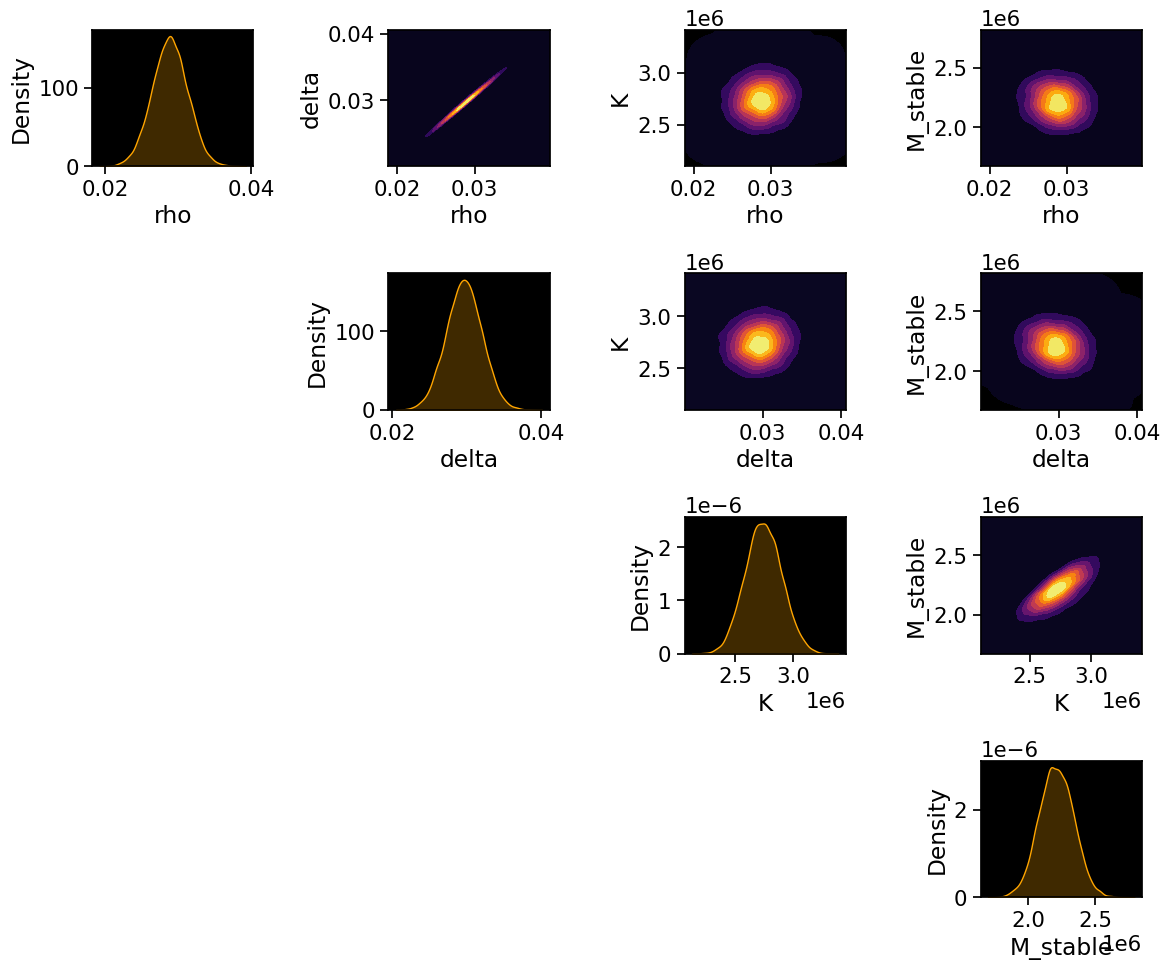

In [6]:
# parameter names based on the Stan model
param_names = ['rho', 'delta', 'K', 'M_stable']

# plot bivariate distribution for all parameters
fig, axes = plt.subplots(len(param_names), len(param_names), figsize=(12, 10))
for i in range(len(param_names)):
    for j in range(len(param_names)):
        axes[i, j].set_facecolor('black')  # Set axes background to black
        if i == j:
            sns.kdeplot(x=posterior[param_names[i]], ax=axes[i, j], fill=True, color='orange')
            axes[i, j].set_xlabel(param_names[i])
            axes[i, j].set_ylabel('Density')
        elif i < j:
            sns.kdeplot(x=posterior[param_names[i]], y=posterior[param_names[j]], fill=True, cmap='inferno', thresh=0, levels=10, ax=axes[i, j])
            axes[i, j].set_xlabel(param_names[i])
            axes[i, j].set_ylabel(param_names[j])
        else:
            axes[i, j].axis('off')
plt.tight_layout()
plt.show()

In [7]:
phi_SHM = SHM_df.stan_variable('phi')
rho_SHM = SHM_df.stan_variable('rho')
M_stable_SHM = SHM_df.stan_variable('MZ_counts_pred1')

# delta_T1 = ((phi_samples * 1298783) / M_stable_samples[:,0] ) + rho_samples
delta_SHM = ((phi_SHM * 1308516) / M_stable_SHM[:,0] ) + rho_SHM

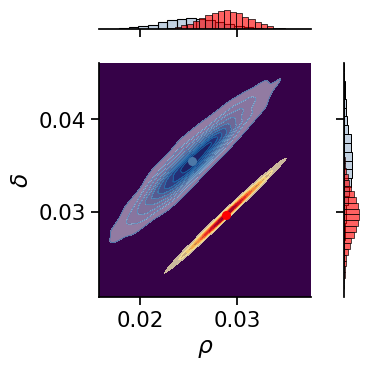

new mean(delta)   = 0.029632
new mean(rho)     = 0.028835
adult mean(delta) = 0.035495
adult mean(rho)   = 0.025330


In [8]:
# Overlay bivariate distributions: neonatal/chimera (posterior) + adults (SHM)
# Neonatal/chimera posterior draws
new_df = pd.DataFrame({
    "delta": posterior["delta"].to_numpy(),
    "rho": posterior["rho"].to_numpy()
})

# Adult posterior draws (use delta directly if available, otherwise derive from phi and stable counts)
adult_df = pd.DataFrame({
    "delta": np.asarray(delta_SHM),
    "rho": np.asarray(rho_SHM)
})

adult_color = "#4C78A8" 
# adult_line = "#1F4E79"
# adult_cmap = sns.light_palette(adult_yellow, as_cmap=True)

# Robust limits (ignore extreme tails so contours don't look tiny)
x_all = np.concatenate([new_df["rho"].to_numpy(), adult_df["rho"].to_numpy()])
y_all = np.concatenate([new_df["delta"].to_numpy(), adult_df["delta"].to_numpy()])

x_low, x_high = np.percentile(x_all, [0.5, 99.5])
y_low, y_high = np.percentile(y_all, [0.5, 99.5])
x_pad = 0.15 * (x_high - x_low)
y_pad = 0.15 * (y_high - y_low)

xlim = (x_low - x_pad, x_high + x_pad)
ylim = (y_low - y_pad, y_high + y_pad) 
g = sns.JointGrid(height=4, space=0.2, xlim=xlim, ylim=ylim)

# Adult in background (fill + contour line)
sns.kdeplot(
    data=adult_df,
    x="rho", y="delta",
    cmap= 'Blues',
    fill=True,
    levels=10,
    # thresh=0.01,
    # bw_adjust=1.15,
    alpha=0.5,
    zorder=1,
    ax=g.ax_joint
)
sns.kdeplot(
    data=adult_df,
    x="rho", y="delta",
    levels=10,
    linewidths=0.5,
    alpha=0.8,
    zorder=2,
    ax=g.ax_joint
)

# Unified on top (fill + contour line)
sns.kdeplot(
    data=new_df,
    x="rho", y="delta",
    fill=True,
    cmap="YlOrRd",
    # cmap="inferno",
    
    # thresh=0.01,
    levels=10,
    # bw_adjust=1.2,
    alpha=0.75,
    zorder=3,
    ax=g.ax_joint
)
# sns.kdeplot(
#     data=new_df,
#     x="rho", y="delta",
#     color="white",
#     levels=10,
#     linewidths=0.6,
#     alpha=0.9,
#     zorder=4,
#     ax=g.ax_joint
# )

# dark background
g.ax_joint.set_facecolor("#360248" )

# Histogram-only marginals (both groups)
sns.histplot(data=adult_df, x="rho", bins=28, kde=False, color=adult_color, alpha=0.34, ax=g.ax_marg_x)
sns.histplot(data=new_df, x="rho", bins=28, kde=False, color='red', alpha=0.62, ax=g.ax_marg_x)

sns.histplot(data=adult_df, y="delta", bins=28, kde=False, color=adult_color, alpha=0.34, ax=g.ax_marg_y)
sns.histplot(data=new_df, y="delta", bins=28, kde=False, color='red', alpha=0.62, ax=g.ax_marg_y)

# Means (optional reference points)
mean_delta_adult, mean_rho_adult = adult_df["delta"].mean(), adult_df["rho"].mean()
mean_delta_new, mean_rho_new = new_df["delta"].mean(), new_df["rho"].mean()

g.ax_joint.scatter(mean_rho_adult, mean_delta_adult, s=30, color="#4C78A8" ,zorder=4)
g.ax_joint.scatter(mean_rho_new, mean_delta_new, s=30, color= 'red',zorder=5)
g.ax_joint.set_xlabel(r'$\rho$')
g.ax_joint.set_ylabel(r'$\delta$')
g.ax_joint.plot([], [], linewidth=1.8, color="#4C78A8")
g.ax_joint.plot([], [], linewidth=1.8, color='Red')


# Set exact major ticks: rho on x-axis, delta on y-axis
g.ax_joint.set_xticks([0.02, 0.03])
g.ax_joint.set_yticks([0.03, 0.04])

plt.tight_layout()
plt.savefig('bivariate_dist_rhodelta1.pdf', dpi=300)
plt.show()

print(f"new mean(delta)   = {mean_delta_new:.6f}")
print(f"new mean(rho)     = {mean_rho_new:.6f}")
print(f"adult mean(delta) = {mean_delta_adult:.6f}")
print(f"adult mean(rho)   = {mean_rho_adult:.6f}")

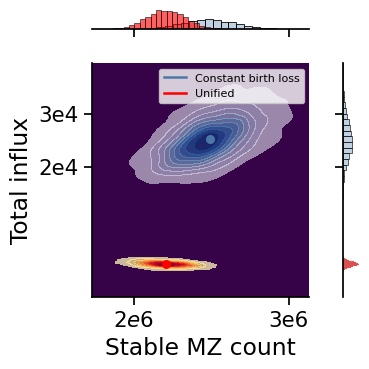

unified mean(total influx) = 1745.52
constant mean(total influx) = 25313.39


In [9]:
# Plot contour distributions for total influx: Unified vs Constant birth-loss

total_influx_shm = np.asarray(phi_SHM) * 1308516
lambda_unified = posterior_df.stan_variable("delta") - posterior_df.stan_variable("rho")
total_influx_unified = lambda_unified * posterior_df.stan_variable("M_stable")

unified_influx_df = pd.DataFrame({
    "Mstable": np.asarray(posterior_df.stan_variable("M_stable")),
    "total_influx": np.asarray(total_influx_unified),
})

constant_influx_df = pd.DataFrame({
    "Mstable": np.asarray(SHM_df.stan_variable("y0")),
    "total_influx": np.asarray(total_influx_shm),
})

adult_color = "#4C78A8"
unified_color = "red"

# Robust limits for clean contour comparison
x_all = np.concatenate([
    unified_influx_df["Mstable"].to_numpy(),
    constant_influx_df["Mstable"].to_numpy(),
])
y_all = np.concatenate([
    unified_influx_df["total_influx"].to_numpy(),
    constant_influx_df["total_influx"].to_numpy(),
])

x_low, x_high = np.percentile(x_all, [0.5, 99.5])
y_low, y_high = np.percentile(y_all, [0.5, 99.5])
x_pad = 0.15 * (x_high - x_low)
y_pad = 0.15 * (y_high - y_low)
xlim = (x_low - x_pad, x_high + x_pad)
ylim = (y_low - y_pad, y_high + y_pad)

g = sns.JointGrid(height=4, space=0.2, xlim=xlim, ylim=ylim)

# Constant birth-loss in background
sns.kdeplot(
    data=constant_influx_df,
    x="Mstable", y="total_influx",
    cmap="Blues",
    fill=True,
    levels=10,
    alpha=0.55,
    zorder=1,
    ax=g.ax_joint
)

# Unified on top
sns.kdeplot(
    data=unified_influx_df,
    x="Mstable", y="total_influx",
    cmap="YlOrRd",
    fill=True,
    levels=10,
    alpha=0.75,
    zorder=2,
    ax=g.ax_joint
)

g.ax_joint.set_facecolor("#360248")

# Marginal histograms
sns.histplot(data=constant_influx_df, x="Mstable", bins=28, kde=False, color=adult_color, alpha=0.34, ax=g.ax_marg_x)
sns.histplot(data=unified_influx_df, x="Mstable", bins=28, kde=False, color=unified_color, alpha=0.62, ax=g.ax_marg_x)
sns.histplot(data=constant_influx_df, y="total_influx", bins=28, kde=False, color=adult_color, alpha=0.34, ax=g.ax_marg_y)
sns.histplot(data=unified_influx_df, y="total_influx", bins=28, kde=False, color=unified_color, alpha=0.62, ax=g.ax_marg_y)

# Means
mean_Mstable_const = constant_influx_df["Mstable"].mean()
mean_influx_const = constant_influx_df["total_influx"].mean()
mean_Mstable_unified = unified_influx_df["Mstable"].mean()
mean_influx_unified = unified_influx_df["total_influx"].mean()

g.ax_joint.scatter(mean_Mstable_const, mean_influx_const, s=30, color=adult_color, zorder=3)
g.ax_joint.scatter(mean_Mstable_unified, mean_influx_unified, s=30, color=unified_color, zorder=4)

g.ax_joint.set_xlabel('Stable MZ count')
g.ax_joint.set_ylabel('Total influx')
g.ax_joint.plot([], [], linewidth=1.8, color=adult_color, label="Constant birth loss")
g.ax_joint.plot([], [], linewidth=1.8, color=unified_color, label="Unified")
g.ax_joint.legend(loc="upper right", fontsize=8)

g.ax_joint.set_xticks([2e6, 3e6])
g.ax_joint.set_xticklabels(['$2e6$', '3e6'])
g.ax_joint.set_yticks([2e4, 3e4])
g.ax_joint.set_yticklabels(['2e4', '3e4'])



plt.tight_layout()
plt.savefig('bivariate_dist_total_influx.pdf', dpi=300)
plt.show()

print(f"unified mean(total influx) = {mean_influx_unified:.2f}")
print(f"constant mean(total influx) = {mean_influx_const:.2f}")

In [10]:
# open experimental data file 
df_new = pd.read_csv('data/New_data/new_data_MZB.csv')
df_new = df_new.sort_values(by='Age at BMT')
df_new['agebin'] = pd.cut(df_new['Age at BMT'], bins=[0,70, 140], labels=['<10 weeks', '>10 weeks'])
df_ont = pd.read_csv('data/Ontogeny_T1.csv')



In [11]:
def P(t):
    theta_0 = np.exp(14.08)
    nu = 0.25
    n = 1.8
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
 
def b(M, b_param, K):
    return b_param * (1 - (M / K))

def b_m(M, rho, M_stable, K):
    b_param = rho / (1 - (M_stable / K))
    return b_param * (1 - (M / K))
 
# Define the ODE function
# Initial conditions at time t=40
M0 = [12058]

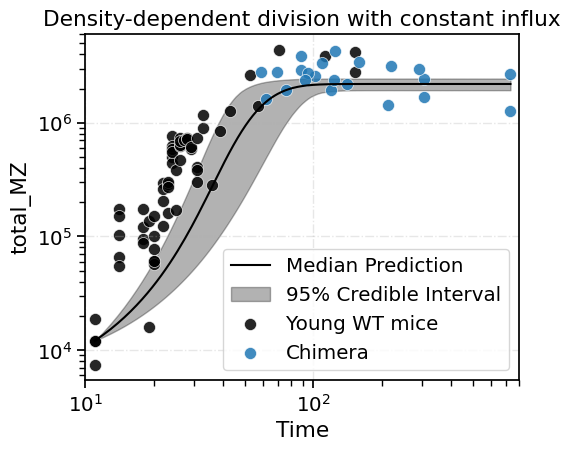

In [38]:
# solve exponential ode using posterior samples
y_pred_samples = []

time_points_counts = np.linspace(11, 732, 750)
model_params = (posterior['rho'], posterior['delta'], posterior['K'], posterior['M_stable'])

for i in range(len(posterior['rho'])):
    rho = posterior['rho'][i]
    delta = posterior['delta'][i]
    k = posterior['K'][i]
    M_stable = posterior['M_stable'][i]
    
    theta_spline = 1308516
    def model_ode(t, M, rho, delta, M_stable, K):
        Lambda = delta - rho
        dMdt = ((Lambda * M_stable)/ theta_spline)*P(t) + b_m(M, rho, M_stable, K) * M - delta * M
        return np.array(dMdt)
    y0_val = [12058]
    y_pred = solve_ivp(model_ode, [11, 732], y0_val, t_eval=time_points_counts, args=(rho, delta, M_stable, k))
    y_pred_samples.append(y_pred.y.flatten())

# Plot results using seaborn
plt.figure(figsize=(5.6, 4.5))
sns.lineplot(x=time_points_counts, y=np.mean(y_pred_samples, axis=0), color='black', label='Median Prediction')
plt.fill_between(time_points_counts,
                 np.percentile(y_pred_samples, 2.5, axis=0),
                 np.percentile(y_pred_samples, 97.5, axis=0),
                 color='black', alpha=0.3, label='95% Credible Interval')
sns.scatterplot(data=df_ont, x='age.at.S1K', y='total_MZ', alpha=0.85, s=75, color= 'black',label='Young WT mice', legend=False, linewidth=0.5)
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85 ,s=75, label='Chimera', legend=False,  linewidth=0.5)
plt.xlabel('Time')
plt.xlim(10, 800)
plt.yscale('log')
# plt.ylabel('Cell counts')
plt.xscale('log')
plt.title('Density-dependent division with constant influx')
plt.legend()
plt.grid(alpha=0.3, linestyle='-.')



In [13]:
def chi_source(time, chi_est=0.85, nu=0.1, t0=10):
    if (time - t0) < 0:
        return 0.0
    else:
        return chi_est * (1 - np.exp(-nu * (time - t0)))
    
def eps_donor(time, m=-3.79e-5, c=0.99, t0=40):
    if (time - t0) < 0:
        return 0.0
    else:
        return m * (time - t0) + c
    
def eps_host(time, m=-1.7e-4, c=0.98, t0=40):
    if (time - t0) < 0:
         return 0.0
    else:
        return m * (time - t0) + c
    
def b(M, rho, M_stable, K):
    b_param = rho / (1 - (M_stable / K))
    return b_param * (1 - (M / K))

In [16]:
def rho_dd(M, rho, K, M_stable):
    """Density-dependent division rate"""
    b_param = rho / (1 - (M_stable / K))
    return b_param * (1 - (M / K))

def ode_sys_unified(time, X, rho, delta, k, M_stable, ageATBMT):
    """
    ODE system for unified model
    
    Parameters:
    -----------
    time : float
        Current time point
    X : array-like
        State vector [donor Ki67+, donor Ki67-, host Ki67+, host Ki67-]
    parms : array-like
        Parameters [rho, delta, K, M_stable, ageATBMT]
    
    Returns:
    --------
    dXdt : numpy array
        Derivatives of state variables
    """
    
    # Fixed parameters
    beta = 3.5
    theta_spline = 1308516
    # Calculated parameters
    lamda = delta - rho  # net loss rate
    S = lamda * M_stable / theta_spline  # influx rate at time ts
    
    # Total cell count
    M_total = X[0] + X[1] + X[2] + X[3]
    
    # Calculate density-dependent division rate
    rho_dens = b(M_total, rho, M_stable, k)
    
    # Initialize derivatives
    dXdt = np.zeros(4)
    
    # Donor Ki67+ cells
    dXdt[0] = (S * eps_donor(time) * chi_source(time - ageATBMT)* theta_spline + 
               rho_dens * (X[0] + 2 * X[1]) - ((1 / beta) + delta) * X[0])
    
    # Donor Ki67- cells
    dXdt[1] = (S * (1 - eps_donor(time)) * chi_source(time - ageATBMT)* theta_spline + 
               (1 / beta) * X[0] - (rho_dens + delta) * X[1])
    
    # Host Ki67+ cells
    dXdt[2] = (S * eps_host(time) * (1 - chi_source(time - ageATBMT)) * theta_spline + 
               rho_dens * (X[2] + 2 * X[3]) - ((1 / beta) + delta) * X[2])
    
    # Host Ki67- cells
    dXdt[3] = (S * (1 - eps_host(time)) * (1 - chi_source(time - ageATBMT)) * theta_spline + 
               (1 / beta) * X[2] - (rho_dens + delta) * X[3])
    
    return dXdt

In [17]:
model_params = (posterior['rho'], posterior['delta'], posterior['K'], posterior['M_stable'])

In [24]:
phi_samples = ((posterior['delta'] - posterior['rho']) * posterior['M_stable']) / 1308516
phi_mean = np.mean(phi_samples)
phi_q = np.percentile(phi_samples, [2.5, 50, 97.5])

print(f"S mean: {phi_mean}, 95% CI: [{phi_q[0]}, {phi_q[1]}, {phi_q[2]}]")

S mean: 0.0013339672485726019, 95% CI: [0.0006101449590699297, 0.0013240364103617366, 0.002099260831356172]


In [19]:
# solve exponential ode using posterior samples
y_pred_chi_bin1 = []
y_pred_chi_bin2 = []

time_points_bin1 = np.linspace(41, 750, 750)
time_points_bin2 = np.linspace(74, 750, 750)

for i in range(len(posterior['rho'])):
    rho = posterior['rho'][i]
    delta = posterior['delta'][i]
    k = posterior['K'][i]
    M_stable = posterior['M_stable'][i]
    kappa_0 = 0.16
    # Initial conditions at time t=40
    N0 = solve_ivp(model_ode, [11, 41], M0, t_eval=[41], args=(rho, delta, k, M_stable))
    initial_cond = np.concatenate(([0.0, 0.0], N0.y[:, -1] * kappa_0, N0.y[:, -1] * (1 - kappa_0)))
    y_pred1 = solve_ivp(ode_sys_unified, [10, 750], initial_cond, t_eval=time_points_bin1, args=(rho, delta, k, M_stable, 41))
    y_pred_chi_bin1.append(y_pred1.y.flatten())
    y_pred2 = solve_ivp(ode_sys_unified, [10, 750], initial_cond, t_eval=time_points_bin2, args=(rho, delta, k, M_stable, 74))
    y_pred_chi_bin2.append(y_pred2.y.flatten())


In [20]:
# shape of y_pred_chi_bin1 and y_pred_chi_bin2
y_pred_chi_bin1 = np.array(y_pred_chi_bin1).reshape(len(posterior['rho']), 4, len(time_points_bin1))
y_pred_chi_bin2 = np.array(y_pred_chi_bin2).reshape(len(posterior['rho']), 4, len(time_points_bin2))
y_pred_chi_bin1.shape, y_pred_chi_bin2.shape

((10000, 4, 750), (10000, 4, 750))

In [21]:

# Compute time-series predictions for Nfd and Ki67 proportions (vectorized)
# For agebin1 (ageATBMT = 41)
chi1 = np.array([chi_source(t - 41) for t in time_points_bin1])
Nfd1_median = np.median((y_pred_chi_bin1[:, 0, :] + y_pred_chi_bin1[:, 1, :]) / ((y_pred_chi_bin1[:, 0, :] + y_pred_chi_bin1[:, 1, :] + y_pred_chi_bin1[:, 2, :] + y_pred_chi_bin1[:, 3, :])  * chi1), axis=0)
donor_ki_pred1_median = np.median(y_pred_chi_bin1[:, 0, :] / (y_pred_chi_bin1[:, 0, :] + y_pred_chi_bin1[:, 1, :]), axis=0)
host_ki_pred1_median = np.median(y_pred_chi_bin1[:, 2, :] / (y_pred_chi_bin1[:, 2, :] + y_pred_chi_bin1[:, 3, :]), axis=0)

# lower bound
Nfd1_lb = np.percentile((y_pred_chi_bin1[:, 0, :] + y_pred_chi_bin1[:, 1, :]) / ((y_pred_chi_bin1[:, 0, :] + y_pred_chi_bin1[:, 1, :] + y_pred_chi_bin1[:, 2, :] + y_pred_chi_bin1[:, 3, :])  * chi1), 2.5, axis=0)
donor_ki_pred1_lb = np.percentile(y_pred_chi_bin1[:, 0, :] / (y_pred_chi_bin1[:, 0, :] + y_pred_chi_bin1[:, 1, :]), 2.5, axis=0)
host_ki_pred1_lb = np.percentile(y_pred_chi_bin1[:, 2, :] / (y_pred_chi_bin1[:, 2, :] + y_pred_chi_bin1[:, 3, :]), 2.5, axis=0)

# upper bound
Nfd1_ub = np.percentile((y_pred_chi_bin1[:, 0, :] + y_pred_chi_bin1[:, 1, :]) / ((y_pred_chi_bin1[:, 0, :] + y_pred_chi_bin1[:, 1, :] + y_pred_chi_bin1[:, 2, :] + y_pred_chi_bin1[:, 3, :])  * chi1), 97.5, axis=0)
donor_ki_pred1_ub = np.percentile(y_pred_chi_bin1[:, 0, :] / (y_pred_chi_bin1[:, 0, :] + y_pred_chi_bin1[:, 1, :]), 97.5, axis=0)
host_ki_pred1_ub = np.percentile(y_pred_chi_bin1[:, 2, :] / (y_pred_chi_bin1[:, 2, :] + y_pred_chi_bin1[:, 3, :]), 97.5, axis=0)    

# For agebin2 (ageATBMT = 74)
chi2 = np.array([chi_source(t - 74) for t in time_points_bin2])
Nfd2_median = np.median((y_pred_chi_bin2[:, 0, :] + y_pred_chi_bin2[:, 1, :]) / ((y_pred_chi_bin2[:, 0, :] + y_pred_chi_bin2[:, 1, :] + y_pred_chi_bin2[:, 2, :] + y_pred_chi_bin2[:, 3, :])  * chi2), axis=0)
donor_ki_pred2_median = np.median(y_pred_chi_bin2[:, 0, :] / (y_pred_chi_bin2[:, 0, :] + y_pred_chi_bin2[:, 1, :]), axis=0)
host_ki_pred2_median = np.median(y_pred_chi_bin2[:, 2, :] / (y_pred_chi_bin2[:, 2, :] + y_pred_chi_bin2[:, 3, :]), axis=0)

# lower bound
Nfd2_lb = np.percentile((y_pred_chi_bin2[:, 0, :] + y_pred_chi_bin2[:, 1, :]) / ((y_pred_chi_bin2[:, 0, :] + y_pred_chi_bin2[:, 1, :] + y_pred_chi_bin2[:, 2, :] + y_pred_chi_bin2[:, 3, :])  * chi2), 2.5, axis=0)
donor_ki_pred2_lb = np.percentile(y_pred_chi_bin2[:, 0, :] / (y_pred_chi_bin2[:, 0, :] + y_pred_chi_bin2[:, 1, :]), 2.5, axis=0)
host_ki_pred2_lb = np.percentile(y_pred_chi_bin2[:, 2, :] / (y_pred_chi_bin2[:, 2, :] + y_pred_chi_bin2[:, 3, :]), 2.5, axis=0)

# upper bound
Nfd2_ub = np.percentile((y_pred_chi_bin2[:, 0, :] + y_pred_chi_bin2[:, 1, :]) / ((y_pred_chi_bin2[:, 0, :] + y_pred_chi_bin2[:, 1, :] + y_pred_chi_bin2[:, 2, :] + y_pred_chi_bin2[:, 3, :])  * chi2), 97.5, axis=0)
donor_ki_pred2_ub = np.percentile(y_pred_chi_bin2[:, 0, :] / (y_pred_chi_bin2[:, 0, :] + y_pred_chi_bin2[:, 1, :]), 97.5, axis=0)
host_ki_pred2_ub = np.percentile(y_pred_chi_bin2[:, 2, :] / (y_pred_chi_bin2[:, 2, :] + y_pred_chi_bin2[:, 3, :]), 97.5, axis=0)

/tmp/ipykernel_457464/4019998542.py:4: RuntimeWarning: divide by zero encountered in divide
  Nfd1_median = np.median((y_pred_chi_bin1[:, 0, :] + y_pred_chi_bin1[:, 1, :]) / ((y_pred_chi_bin1[:, 0, :] + y_pred_chi_bin1[:, 1, :] + y_pred_chi_bin1[:, 2, :] + y_pred_chi_bin1[:, 3, :])  * chi1), axis=0)
/tmp/ipykernel_457464/4019998542.py:4: RuntimeWarning: invalid value encountered in divide
  Nfd1_median = np.median((y_pred_chi_bin1[:, 0, :] + y_pred_chi_bin1[:, 1, :]) / ((y_pred_chi_bin1[:, 0, :] + y_pred_chi_bin1[:, 1, :] + y_pred_chi_bin1[:, 2, :] + y_pred_chi_bin1[:, 3, :])  * chi1), axis=0)
/tmp/ipykernel_457464/4019998542.py:5: RuntimeWarning: invalid value encountered in divide
  donor_ki_pred1_median = np.median(y_pred_chi_bin1[:, 0, :] / (y_pred_chi_bin1[:, 0, :] + y_pred_chi_bin1[:, 1, :]), axis=0)
/tmp/ipykernel_457464/4019998542.py:9: RuntimeWarning: divide by zero encountered in divide
  Nfd1_lb = np.percentile((y_pred_chi_bin1[:, 0, :] + y_pred_chi_bin1[:, 1, :]) / ((y_pred

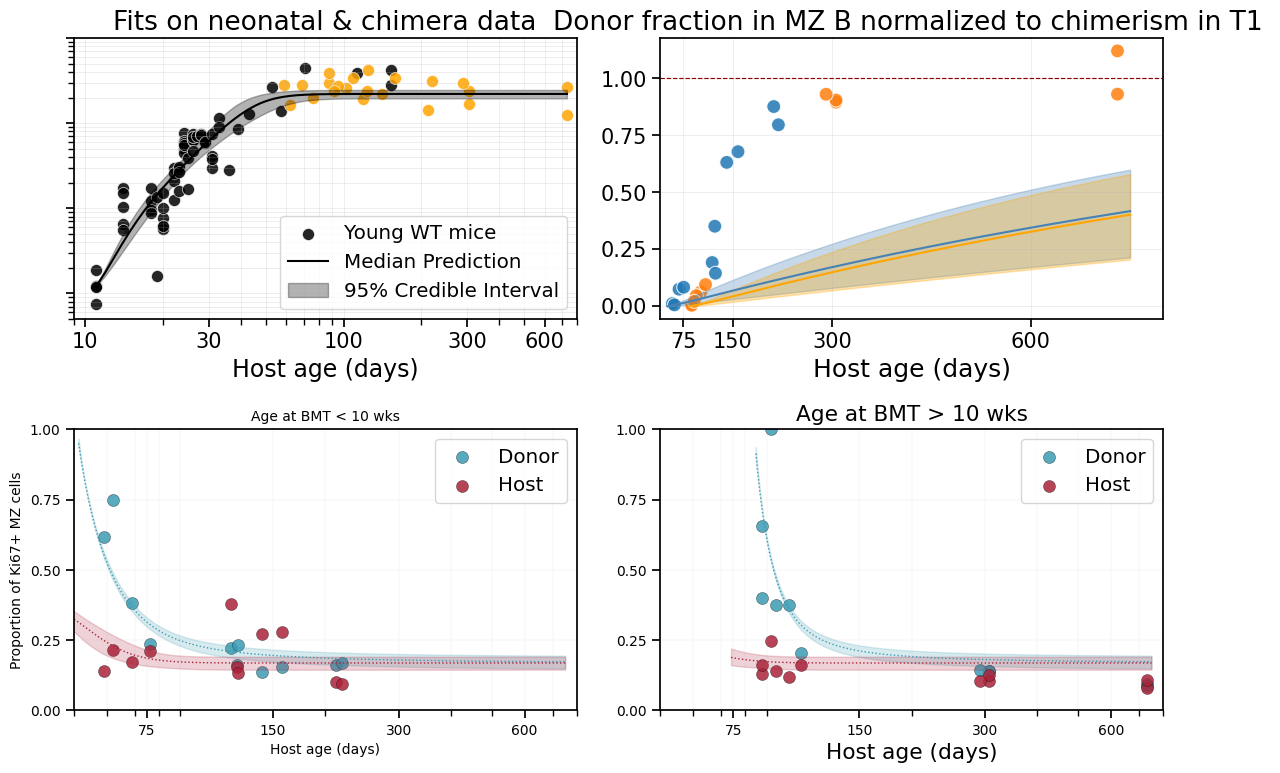

In [23]:
# global font size
sns.set_context("notebook", font_scale=1.3)

# Create a figure with a custom grid layout
fig, axes = plt.subplots(2, 2, figsize=(12, 8), gridspec_kw={'height_ratios': [1, 1]})
ax1 = axes[0, 0]
ax2 = axes[0, 1]
# ax3 and ax4 will be used later for Ki67 plots
ax3 = axes[1, 0]
ax4 = axes[1, 1]

# Plot the Mz counts on ax1
sns.scatterplot(ax=ax1, data=df_ont, x='age.at.S1K', y='total_MZ', alpha=0.85, s=75, color='black', label='Young WT mice', legend=False, linewidth=0.5)
sns.scatterplot(ax=ax1, data=df_new, x='Age at S1K', y='total_MZ', alpha=0.85, s=75, color='orange', legend=False, linewidth=0.5)

# plot model prediction on ax1
#ax1.plot(t_ev1, N0, color='steelblue', label='T1')
ax1.plot(time_points_counts, np.median(y_pred_samples, axis=0), color='black', label='Median Prediction')
ax1.fill_between(time_points_counts,
                 np.percentile(y_pred_samples, 2.5, axis=0),
                 np.percentile(y_pred_samples, 97.5, axis=0),
                 color='black', alpha=0.3, label='95% Credible Interval')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_ylim(5 * 1e3, 1e7)
ax1.set_xlim(9, 800)
ax1.set_xticks([10, 30, 100, 300, 600])
ax1.set_xticklabels([10, 30, 100, 300, 600])
ax1.set_title('Fits on neonatal & chimera data', fontsize=19)
ax1.set_xlabel('Host age (days)', fontsize=17)
ax1.set_ylabel('')
ax1.set_yticklabels([])
ax1.tick_params(axis='both', labelsize=15)
ax1.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
ax1.legend()


# Plot normalized donor fraction on ax2
sns.scatterplot(ax=ax2, data=df_new, x='Age at S1K', y='Nfd_MZ', hue='agebin', alpha=0.85, s=100, legend=False)
sns.lineplot(ax=ax2, x=time_points_bin1, y=Nfd1_median, color='steelblue')
sns.lineplot(ax=ax2, x=time_points_bin2, y=Nfd2_median, color='orange')
ax2.fill_between(time_points_bin1,
                 Nfd1_lb,
                 Nfd1_ub,
                 color='steelblue', alpha=0.3)
ax2.fill_between(time_points_bin2,
                 Nfd2_lb,
                 Nfd2_ub,
                 color='orange', alpha=0.3)
ax2.set_yscale('linear')
ax2.set_xscale('linear')
ax2.set_xlim(40, 800)
ax2.set_xticks([75, 150, 300, 600])
ax2.set_xticklabels([75, 150, 300, 600])
ax2.set_ylabel('')
ax2.set_yticks(np.arange(0, 1.25, 0.25))
ax2.set_xlabel('Host age (days)', fontsize=18)
ax2.set_title('Donor fraction in MZ B normalized to chimerism in T1 ', fontsize=19)
ax2.axhline(y=1, color='darkred', linestyle='dashed', linewidth=0.85)
ax2.tick_params(axis='both', labelsize=15)
ax2.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)

#Construct a new dataframe for agebin1, agebin2 
df_Ki67_bin1 = df_new[df_new['agebin'] == '<10 weeks']
df_Ki67_bin2 = df_new[df_new['agebin'] == '>10 weeks']


# Subplot 1: Age bin 1 (< 10 weeks)
sns.scatterplot(ax=ax3, data=df_Ki67_bin1, x='Age at S1K', y='frac_Ki67+_MZ_donor', edgecolor='black', linewidth=0.25, alpha=0.85, s=75, color='#3b9bb3', label='Donor')
sns.scatterplot(ax=ax3, data=df_Ki67_bin1, x='Age at S1K', y='frac_Ki67+_MZ_host', edgecolor='black', linewidth=0.25, alpha=0.85, s=75, color='#ab2239', label='Host')

ax3.plot(time_points_bin1, donor_ki_pred1_median, color='#3b9bb3', linestyle='dotted', linewidth=1)
ax3.fill_between(time_points_bin1, donor_ki_pred1_lb, donor_ki_pred1_ub, color='#3b9bb3', alpha=0.2)
ax3.plot(time_points_bin1, host_ki_pred1_median, color='#ab2239', linestyle='dotted', linewidth=1)
ax3.fill_between(time_points_bin1, host_ki_pred1_lb, host_ki_pred1_ub, color='#ab2239', alpha=0.2)

ax3.set_xlim(50, 800)
ax3.set_ylim(0, 1)
ax3.set_xscale('log')
ax3.set_xticks([75, 150, 300, 600])
ax3.set_xticklabels([75, 150, 300, 600])
ax3.set_ylabel('Proportion of Ki67+ MZ cells', fontsize=10)
ax3.set_yticks(np.arange(0, 1.25, 0.25))
ax3.set_title('Age at BMT < 10 wks', fontsize=10)
ax3.set_xlabel('Host age (days)', fontsize=10)
ax3.tick_params(axis='both', labelsize=10)
ax3.grid(True, which='both', ls="solid", linewidth=0.25, alpha=0.3)
ax3.legend()

sns.scatterplot(ax=ax4, data=df_Ki67_bin2, x='Age at S1K', y='frac_Ki67+_MZ_donor', edgecolor='black', linewidth=0.25, alpha=0.85, s=75, color='#3b9bb3', label='Donor')
sns.scatterplot(ax=ax4, data=df_Ki67_bin2, x='Age at S1K', y='frac_Ki67+_MZ_host', edgecolor='black', linewidth=0.25, alpha=0.85, s=75, color='#ab2239', label='Host')

ax4.plot(time_points_bin2, donor_ki_pred2_median, color='#3b9bb3', linestyle='dotted', linewidth=1)
ax4.fill_between(time_points_bin2, donor_ki_pred2_lb, donor_ki_pred2_ub, color='#3b9bb3', alpha=0.2)
ax4.plot(time_points_bin2, host_ki_pred2_median, color='#ab2239', linestyle='dotted', linewidth=1)
ax4.fill_between(time_points_bin2, host_ki_pred2_lb, host_ki_pred2_ub, color='#ab2239', alpha=0.2)

ax4.set_xlim(50, 800)
ax4.set_ylim(0, 1)
ax4.set_xscale('log')
ax4.set_xticks([75, 150, 300, 600])
ax4.set_xticklabels([75, 150, 300, 600])
ax4.set_ylabel('')
ax4.set_yticks(np.arange(0, 1.25, 0.25))
ax4.set_title('Age at BMT > 10 wks')
ax4.set_xlabel('Host age (days)')
ax4.tick_params(axis='both', labelsize=10)
ax4.grid(True, which='both', ls="solid", linewidth=0.25, alpha=0.3)
ax4.legend()

plt.tight_layout()
#save figure
# plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/UnifiedModelFeedback_T2.pdf', dpi=300)
plt.show() 

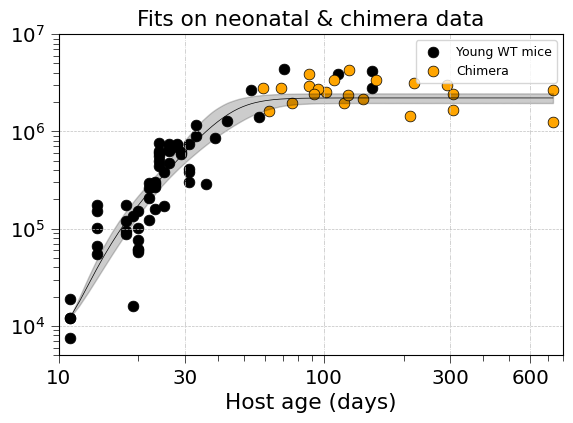

In [25]:
#Plot Mz counts for three precursors


fig = plt.subplots(figsize=(6, 4.5))
ts1= np.arange(52, 750, 1)
# Plot the Mz counts 
sns.scatterplot(data=df_ont, x='age.at.S1K', y='total_MZ', s=60, color='black', edgecolor='black', linewidth=0.5, label='Young WT mice', legend=False)
sns.scatterplot(data=df_new, x='Age at S1K', y='total_MZ', s=60, color='orange', edgecolor='black', linewidth=0.5, label='Chimera', legend=False)

# plot model prediction on ax1
#ax1.plot(t_ev1, N0, color='steelblue', label='T1')
plt.plot(time_points_counts, np.median(y_pred_samples, axis=0), color='black', linewidth=0.5)
# plt.plot(ts1, np.mean(SHM_df.MZ_counts_pred1, axis=0), color='blue', linewidth=1)
# plt.axhline(y=np.mean(), color='red', linestyle='dashed', linewidth=0.5)
plt.fill_between(time_points_counts,
                 np.percentile(y_pred_samples, 2.5, axis=0),
                 np.percentile(y_pred_samples, 97.5, axis=0),
                 color='black', alpha=0.2)
plt.xscale('log')
plt.yscale('log')
plt.ylim(5*1e3, 1e7)
plt.xlim(10, 800)
# plt.xticks([10, 30, 100, 300, 600])
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.xlabel('Host age (days)')
plt.ylabel('')
ax = plt.gca()
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight("normal")

ax.tick_params(axis="both", which="both", width=0.5)
for spine in ax.spines.values():
    spine.set_linewidth(0.8)
plt.title('Fits on neonatal & chimera data')
plt.legend(fontsize='xx-small')
# plt.tick_params(axis='both')
plt.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
plt.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
plt.tight_layout()

# plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/TotalCounts_Unified.pdf', dpi=300, transparent=True)
plt.show()

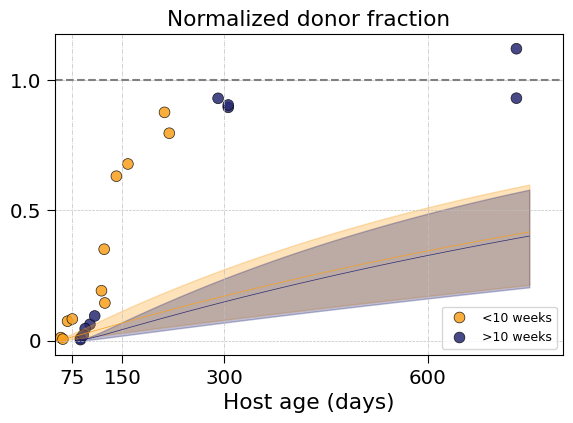

In [36]:

# Plot normalized donor fraction 
my_pal = ["#f99f1b", "#282a73"]
fig = plt.subplots(figsize=(6, 4.5))

sns.scatterplot(data=df_new, x='Age at S1K', y='Nfd_MZ', hue='agebin',  s=60, alpha=0.85, edgecolor='black', linewidth=0.5, palette=my_pal)
sns.lineplot(x=time_points_bin1, y=Nfd1_median, color=my_pal[0], linewidth=0.5)
sns.lineplot(x=time_points_bin2, y=Nfd2_median, color=my_pal[1], linewidth=0.5)
plt.fill_between(time_points_bin1,
                 Nfd1_lb,
                 Nfd1_ub,
                 color=my_pal[0], alpha=0.3)
plt.fill_between(time_points_bin2,
                 Nfd2_lb,
                 Nfd2_ub,
                 color=my_pal[1], alpha=0.3)
plt.yscale('linear')
# plt.xscale('log')
plt.xlim(50, 800)
plt.xticks([75, 150, 300, 600], [75, 150, 300, 600])
plt.ylabel('')
plt.yticks(np.arange(0, 1.25, 0.25))
plt.yticks([0, 0.5, 1.0], [0,  0.5,  1.0])
plt.xlabel('Host age (days)')
plt.title('Normalized donor fraction')
plt.tick_params(axis='both')
plt.legend (fontsize='xx-small')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.8)   # try 0.6 / 0.8 / 1.0

# Tick mark width
ax.tick_params(axis='both', which='both', width=0.8)
plt.axhline(y=1, color='gray', linestyle='dashed')
plt.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
plt.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
plt.tight_layout()

# plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Nfd_Unified.pdf', dpi=300)
plt.show()


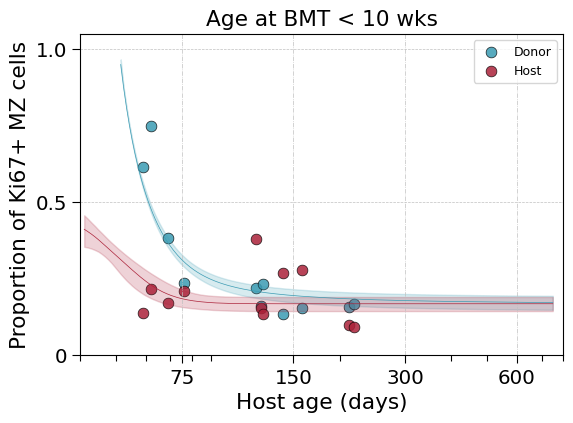

In [27]:

plt.figure(figsize=(6, 4.5))
sns.scatterplot(data=df_Ki67_bin1, x='Age at S1K', y='frac_Ki67+_MZ_donor', edgecolor='black', linewidth=0.5, alpha=0.85, s=60, color='#3b9bb3', label='Donor')
sns.scatterplot(data=df_Ki67_bin1, x='Age at S1K', y='frac_Ki67+_MZ_host', edgecolor='black', linewidth=0.5, alpha=0.85, s=60, color='#ab2239', label='Host')

plt.plot(time_points_bin1, donor_ki_pred1_median, color='#3b9bb3', linewidth=0.5)
plt.fill_between(time_points_bin1, donor_ki_pred1_lb, donor_ki_pred1_ub, color='#3b9bb3', alpha=0.2)
plt.plot(time_points_bin1, host_ki_pred1_median, color='#ab2239', linewidth=0.5)
plt.fill_between(time_points_bin1, host_ki_pred1_lb, host_ki_pred1_ub, color='#ab2239', alpha=0.2)
plt.xlim(40, 800)
plt.ylim(0, 1.05)
plt.xscale('log')
plt.xticks([75, 150, 300, 600], [75, 150, 300, 600])
plt.ylabel('')
plt.yticks(np.arange(0, 1.25, 0.25))
plt.yticks([0, 0.5, 1.0], [0,  0.5,  1.0])
plt.ylabel('Proportion of Ki67+ MZ cells')
plt.title('Age at BMT < 10 wks')
plt.xlabel('Host age (days)')
plt.legend (fontsize='xx-small')
plt.tick_params(axis='both')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.8)   # try 0.6 / 0.8 / 1.0

# Tick mark width
ax.tick_params(axis='both', which='both', width=0.8)
plt.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
plt.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
plt.tight_layout()
# plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Ki67+fraction_Agebin1_Unified.pdf', dpi=300)
plt.show() 

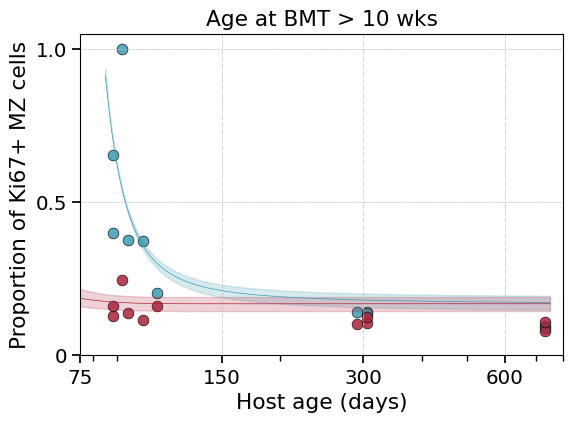

In [28]:

plt.figure(figsize=(6, 4.5))
sns.scatterplot(data=df_Ki67_bin2, x='Age at S1K', y='frac_Ki67+_MZ_donor', edgecolor='black', linewidth=0.5, alpha=0.85, s=60, color='#3b9bb3', legend=False,label='Donor')
sns.scatterplot(data=df_Ki67_bin2, x='Age at S1K', y='frac_Ki67+_MZ_host', edgecolor='black', linewidth=0.5, alpha=0.85, s=60, color='#ab2239', legend = False,label='Host')

plt.plot(time_points_bin2, donor_ki_pred2_median, color='#3b9bb3',  linewidth=0.5)
plt.fill_between(time_points_bin2, donor_ki_pred2_lb, donor_ki_pred2_ub, color='#3b9bb3', alpha=0.2)
plt.plot(time_points_bin2, host_ki_pred2_median, color='#ab2239',  linewidth=0.5)
plt.fill_between(time_points_bin2, host_ki_pred2_lb, host_ki_pred2_ub, color='#ab2239', alpha=0.2)

plt.xlim(75, 800)
plt.ylim(0, 1.05)
plt.xscale('log')
plt.xticks([75, 150, 300, 600], [75, 150, 300, 600])
plt.ylabel('')
plt.yticks(np.arange(0, 1.25, 0.25))
plt.yticks([0, 0.5, 1.0], [0,  0.5,  1.0])
plt.ylabel('Proportion of Ki67+ MZ cells')
plt.title('Age at BMT > 10 wks')
plt.xlabel('Host age (days)')
plt.tick_params(axis='both')
ax = plt.gca()
# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.8)   # try 0.6 / 0.8 / 1.0

# Tick mark width
# ax.tick_params(axis='both', which='both', width=0.8)
plt.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
plt.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
plt.tight_layout()
# plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Ki67+fraction_Agebin2_Unified.pdf', dpi=300)
plt.show() 

(1000, 1) (10000,) (10000,) (10000,)
(1000, 10000)


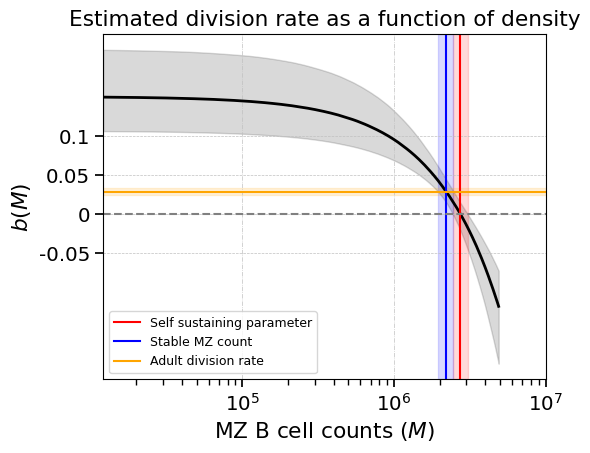

In [29]:
def b(M, rho, M_stable, K):
    b_m = rho / (1 - (M_stable / K))
    return b_m * (1 - (M / K))

M = np.logspace(4.0812756, 6.69, 1000)
# lamda = lamda_samples
# phi = (lamda_samples * M_stable_samples)/ 1308516
rho = posterior_df.rho
M_stable = posterior_df.M_stable
k = posterior_df.K

# Reshape M to broadcast properly with posterior samples
M_broadcast = M[:, np.newaxis]  # Shape: (len(M), 1)
print(M_broadcast.shape, rho.shape, M_stable.shape, k.shape)
b_samples = b(M_broadcast, rho, M_stable, k)  # Shape: (len(M), n_samples)
print(b_samples.shape)


# Calculate statistics
b_median = np.median(b_samples, axis=1)  
b_lower = np.percentile(b_samples, 2.5, axis=1)
b_upper = np.percentile(b_samples, 97.5, axis=1)

# r_mean = np.mean(r_samples, axis=1)

fig, axes = plt.subplots(1, 1, figsize=(6, 4.8))
axes.plot(M, b_median, color='black', linewidth=2)
axes.fill_between(M, b_lower, b_upper, alpha=0.15, color='black')

plt.axvline(x=np.median(posterior_df.K), color='red', label='Self sustaining parameter')
plt.axvspan(np.quantile(posterior_df.K, 0.025), np.quantile(posterior_df.K, 0.975), color='red', alpha=0.15)

plt.axvline(x=np.median(M_stable), color='blue',  label='Stable MZ count')
plt.axvspan(np.quantile(M_stable, 0.025), np.quantile(M_stable, 0.975), color='blue', alpha=0.15)

# plt.axhline(y=np.median(SHM_df.rho), color='black', linestyle='--', label='Adult division rate (SHM)')
# plt.axhspan(np.quantile(SHM_df.rho, 0.025), np.quantile(SHM_df.rho, 0.975), color='black', alpha=0.2)

plt.axhline(y=np.median(posterior_df.rho), color='orange',  label='Adult division rate')
plt.axhspan(np.quantile(posterior_df.rho, 0.025), np.quantile(posterior_df.rho, 0.975), color='orange', alpha=0.15)

plt.axhline(y=0, color='grey', linestyle='--')
axes.set_xlim(12058, 1e7)
axes.set_xticks([1e5, 1e6, 1e7])
axes.set_xticklabels([ '10^5', '10^6', '10^7'])
axes.set_yticks([- 0.05, 0, 0.05, 0.1])
axes.set_yticklabels(['-0.05', '0', '0.05', '0.1'])
axes.set_xscale('log')
axes.set_ylabel(r'$b(M)$')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.8)   # try 0.6 / 0.8 / 1.0
plt.title('Estimated division rate as a function of density')
axes.set_xlabel(r'MZ B cell counts ($\mathit{M}$)')
axes.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
axes.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
axes.legend(fontsize='xx-small')
plt.tight_layout()

#save figure
# plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/b(M)vsMZcounts_Unified.pdf', dpi=300,  bbox_inches='tight')
plt.show()

In [31]:
# Define the birth rate function in terms of t (avoid name clash with variable 'r')
def b_time(rho, M, M_stable, K):
    """Instantaneous logistic birth rate b(M) given parameters."""
    b = rho / (1.0 - (M_stable / K))
    return b * (1.0 - (M / K))

def P(t):
    theta_0 = 14.08
    nu = 0.25
    n = 1.8
    return theta_0 * (1 + (t-10)**n * np.exp(-nu * (t-10)))
   

# Define the ODE function with signature (t, y, *args) required by solve_ivp
def ode_function(t, y, phi, rho, delta, M_stable, K):
    M_val = y[0]
    # dMdt = phi * P(t) + b_time(rho, M_val, M_stable, K) * M_val - delta*M_val
    dMdt = phi + b_time(rho, M_val, M_stable, K) * M_val - delta*M_val
    
    return [dMdt]

# Use posterior means (or derive S from posterior samples)
phi = (posterior_df.delta - posterior_df.rho) * posterior_df.M_stable
rho = posterior_df.rho
delta = posterior_df.delta
M_stable = posterior_df.M_stable
K = posterior_df.K

# Compute S using posterior samples to get a representative mean source if desired
# This avoids mixing scalar means incorrectly.
# S = lamda * data_neutral.M_stable

M0 = [12058.0]
# use a reasonable time step (very small dt can make solver struggle); 0.1 matches other cells
t_ev = np.arange(11.0, 750.0, 0.1)
sol = np.zeros((len(rho), len(t_ev)))
for i in range(len(rho)):
    # Solve once over the full interval (vectorized call) instead of calling solve_ivp in a loop
    result = solve_ivp(ode_function,
                        [t_ev[0], t_ev[-1]],
                M0,
                t_eval=t_ev,
                args=(phi[i], rho[i], delta[i], M_stable[i], K[i]))
    sol[i, :] = result.y[0]

# Extract solution and compute r(t)
b_t = np.zeros((len(t_ev), len(rho)))
for i in range(len(rho)):
    M_t = sol[i, :]
    b_t[:, i] = b_time(rho[i], M_t, M_stable[i], K[i])

# Calculate statistics
b_median = np.median(b_t, axis=1)
b_lower = np.percentile(b_t, 2.5, axis=1)
b_upper = np.percentile(b_t, 97.5, axis=1)

fig, axes = plt.subplots(1, 1, figsize=(6, 4.8))
axes.plot(t_ev, b_median, color='black', linewidth=2)
axes.fill_between(t_ev, b_lower, b_upper, alpha=0.15, color='black')
# plt.axhline(y=0, color='grey', linestyle='--')
# plt.axhline(y=-np.mean(data_DDM.stan_variable('lambda'), axis=0), color='orange', linestyle='--', label='Growth Rate')
# plt.yscale('log')
plt.axhline(y=np.median(SHM_df.rho), color='orange', label='Average division rate for chimeras')
plt.axhspan(np.quantile(SHM_df.rho, 0.025), np.quantile(SHM_df.rho, 0.975), color='orange', alpha=0.15)
# plt.axhline(y=np.median(posterior_df.rho), color='orange', linestyle='--', label='Adult division rate (Ontogeny)')
# plt.axhspan(np.quantile(posterior_df.rho, 0.025), np.quantile(posterior_df.rho, 0.975), color='orange', alpha=0.2)
axes.set_ylim(0, 0.16)
plt.yticks([0.0, 0.05, 0.1, 0.15], [0.0, 0.05, 0.1, 0.15])
axes.set_xlim(11, 740)
plt.xscale('log')
plt.xticks([ 30, 100, 300], [ 30, 100, 300])
axes.set_ylabel('')
ax = plt.gca()

# Axis border width
for spine in ax.spines.values():
    spine.set_linewidth(0.8)   # try 0.6 / 0.8 / 1.0

# Tick mark width
ax.tick_params(axis='both', which='both', width=0.8)
plt.title('Estimated division rate as a function of time')
axes.set_ylabel(r'$b(t)$')
axes.set_xlabel('Host age (days)')
axes.grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
axes.grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
plt.tight_layout()
plt.legend(fontsize='12')
#save figure
#plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/b(M(t)vsAge_Unified.pdf', dpi=300)
plt.show()

ValueError: could not broadcast input array from shape (791,) into shape (7390,)

/tmp/ipykernel_457464/644114692.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


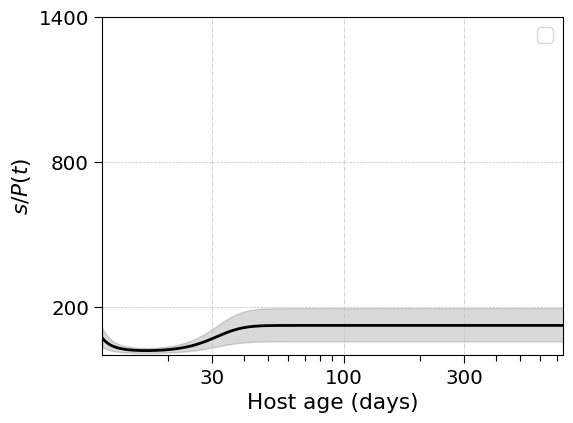

In [32]:
# Plot phi vs time to show source term dynamics

Lambda = delta - rho
s = Lambda * M_stable

# def P(t):
#     theta_0 = 14.1
#     nu = 0.25
#     n = 1.8
#     return theta_0 * (1 + (t - 10)**n * np.exp(-nu * (t - 10)))

def P(t):
    theta_0 = 14.1
    nu = 0.31
    n = 2
    return theta_0 * (1 + (t - 10)**n * np.exp(-nu * (t - 10)))

# Compute s / P(t) as samples x time
P_t = P(t_ev)
s_over_P = s[:, np.newaxis] / P_t

# Summarize across posterior samples for each timepoint
s_over_P_median = np.median(s_over_P, axis=0)
s_over_P_lower = np.percentile(s_over_P, 2.5, axis=0)
s_over_P_upper = np.percentile(s_over_P, 97.5, axis=0)

plt.figure(figsize=(6, 4.5))
plt.plot(t_ev, s_over_P_median, color='black', linewidth=2)
plt.fill_between(t_ev, s_over_P_lower, s_over_P_upper, alpha=0.15, color='black')
# plt.axhline(y=1, color='red', linestyle='--', label=r'$\phi(t) = P(t)$')
# plt.axhline(y=0, color='grey', linestyle='--')
plt.xscale('log')
plt.xticks([30, 100, 300], [30, 100, 300])
plt.xlim(11, 740)
# plt.ylim(0, 2)
plt.yticks([200, 800, 1400], [200, 800, 1400])
# plt.title(' s')
plt.xlabel('Host age (days)')
plt.ylabel(r'$s / P(t)$')
ax = plt.gca()

for spine in ax.spines.values():
    spine.set_linewidth(0.8)
ax.tick_params(axis='both', which='both', width=0.8)
plt.grid(True, axis='x', ls='-.', color='silver', linewidth=0.5)
plt.grid(True, axis='y', ls='--', color='silver', linewidth=0.5)
plt.legend()
plt.tight_layout()
# plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/phi(t)_s_over_P_T1.pdf', dpi=300)
plt.show()

In [33]:
phi_samples_T2 = SHM_df.stan_variable('phi')
rho_samples_T2 = SHM_df.stan_variable('rho')
M_stable_samples_T2 = SHM_df.stan_variable('MZ_counts_pred1')
delta_T2 = ((phi_samples_T2 * 1308516) / M_stable_samples_T2[:,0] ) + rho_samples_T2

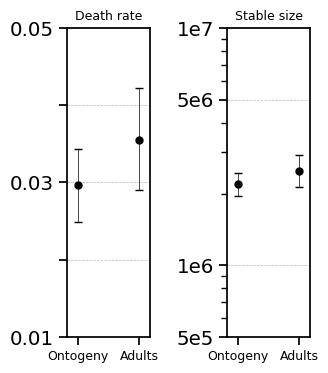

In [34]:
def plot_with_error_bars(data, color, ax, marker='o', label=None):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_data, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt=marker, color=color, capsize=3, markersize=5, elinewidth=1, label=label)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(3.5, 4))

# Plot T1 and T2 with different markers and slight x-offset for clarity
x_offset = 0.5

# Influx rate
# axes[0].errorbar(-x_offset, np.mean(rho), 
#                 yerr=[[np.mean(rho) - np.quantile(rho, 0.025)], 
#                       [np.quantile(rho, 0.975) - np.mean(rho)]], 
#                 fmt='o', color='black', capsize=3, markersize=5, elinewidth=0.5, label='Ontogeny')

# axes[0].errorbar(x_offset, np.mean(rho_samples_T2), 
#                 yerr=[[np.mean(rho_samples_T2) - np.quantile(rho_samples_T2, 0.025)], 
#                       [np.quantile(rho_samples_T2, 0.975) - np.mean(rho_samples_T2)]], 
#                 fmt='o', color='black', capsize=3, markersize=5, elinewidth=0.5, label='Adults')

# Death rate
axes[0].errorbar(-x_offset, np.mean(delta), 
                yerr=[[np.mean(delta) - np.quantile(delta, 0.025)], 
                      [np.quantile(delta, 0.975) - np.mean(delta)]], 
                fmt='o', color='black', capsize=3, markersize=5, elinewidth=0.5, label='Ontogeny')

axes[0].errorbar(x_offset, np.mean(delta_T2), 
                yerr=[[np.mean(delta_T2) - np.quantile(delta_T2, 0.025)], 
                      [np.quantile(delta_T2, 0.975) - np.mean(delta_T2)]], 
                fmt='o', color='black', capsize=3, markersize=5, elinewidth=0.5, label='Adults')

# Stable size
axes[1].errorbar(-x_offset, np.mean(M_stable), 
                yerr=[[np.mean(M_stable) - np.quantile(M_stable, 0.025)], 
                      [np.quantile(M_stable, 0.975) - np.mean(M_stable)]], 
                fmt='o', color='black', capsize=3, markersize=5, elinewidth=0.5, label='Ontogeny')

axes[1].errorbar(x_offset, np.mean(M_stable_samples_T2), 
                yerr=[[np.mean(M_stable_samples_T2) - np.quantile(M_stable_samples_T2, 0.025)], 
                      [np.quantile(M_stable_samples_T2, 0.975) - np.mean(M_stable_samples_T2)]], 
                fmt='o', color='black', capsize=3, markersize=5, elinewidth=0.5, label='Adults')

# Formatting
for i, ax in enumerate(axes):
#     ax.set_ylim(0, 100)
#     ax.set_yticks([0, 30, 50, 70, 90])
    ax.set_xticks([])
    ax.set_xlim(-0.68, 0.68)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

# axes[0].set_yticks([0.010, 0.015, 0.020, 0.025, 0.030, 0.035, 0.040])
# axes[0].set_yticklabels([0.010, '', 0.020, '', 0.030, '', 0.040])
# axes[0].set_title('Division rate', fontsize=9)
# axes[0].legend(fontsize=8, loc='upper right')

# place xticks under the two plotted points and label them explicitly
# axes[0].set_xticks([-x_offset, x_offset])
# axes[0].set_xticklabels(['Ontogeny', 'Adults'], fontsize=8)

axes[0].set_yticks([0.01, 0.020, 0.030, 0.040, 0.050])
# axes[1].set_yticklabels([])
axes[0].set_yticklabels([0.01, '', 0.030, '', 0.050])
axes[0].set_title('Death rate', fontsize=9)
axes[0].set_xticks([-x_offset, x_offset])
axes[0].set_xticklabels(['Ontogeny', 'Adults'], fontsize=9)

axes[1].set_ylim(5e5, 1e7)
axes[1].set_yscale('log')
axes[1].set_yticks([5e5, 1e6, 5e6, 1e7])
axes[1].set_yticklabels(['5e5', '1e6', '5e6', '1e7'])
axes[1].set_title('Stable size', fontsize=9)
axes[1].set_xticks([-x_offset, x_offset])
axes[1].set_xticklabels(['Ontogeny', 'Adults'], fontsize=9)

# Adjust layout
plt.tight_layout()
# plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/SharedParameters.pdf', dpi=300)
plt.show()

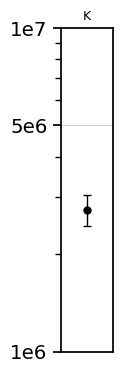

In [35]:
#Plot K

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=3, markersize=5, elinewidth=1)
    
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))
plot_with_error_bars(K, '' ,'black', ax)
# ax.set_ylim(100, 550)
# ax.set_yticks([100, 200, 300, 400, 500])
# ax.set_yticklabels(['100', '', '300', '', '500'], fontsize=10)
ax.set_ylim(1e6, 1e7)
ax.set_yscale('log')
ax.set_yticks([1e6, 5e6, 1e7])
ax.set_yticklabels(['1e6', '5e6', '1e7'])
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('K', fontsize=9)
# ax.set_xlabel('Turnover \n Time', fontsize=10)


ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)
plt.tight_layout()
# plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Ontogeny_K_parameter.pdf', dpi=300)
plt.show()